In [228]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.autograd as autograd
import torch.optim as optim
import torch.nn.functional as F

In [229]:
!pip install scikit-learn

In [230]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if(torch.cuda.is_available()):
    print(f"GPU available: {torch.cuda.get_device_name()}")
    gpu = True
else:
    print("No GPU available")

GPU available: NVIDIA GeForce RTX 5050 Laptop GPU


In [231]:
matches_path = "data/Matches.csv"

df = pd.read_csv(matches_path)
print(df.shape)

(230557, 48)


/tmp/ipykernel_1321315/4087795544.py:3: DtypeWarning: Columns (0: MatchTime) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(matches_path)


In [232]:
features_to_drop = [
    'HTResult', 'OddHome', 'OddDraw', 'Form3Home', 'Form3Away',
    'OddAway', 'MaxHome', 'MaxDraw', 'MaxAway', 
    'Over25', 'Under25', 'MaxOver25', 'MaxUnder25', 
    'HandiSize', 'HandiHome', 'HandiAway', 
]

thin_df = df.drop(features_to_drop, axis="columns")
thin_df = thin_df.dropna()
print(thin_df.shape)
thin_df.info()

(31426, 32)
<class 'pandas.DataFrame'>
Index: 31426 entries, 162577 to 230556
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Division     31426 non-null  str    
 1   MatchDate    31426 non-null  str    
 2   MatchTime    31426 non-null  str    
 3   HomeTeam     31426 non-null  str    
 4   AwayTeam     31426 non-null  str    
 5   HomeElo      31426 non-null  float64
 6   AwayElo      31426 non-null  float64
 7   Form5Home    31426 non-null  float64
 8   Form5Away    31426 non-null  float64
 9   FTHome       31426 non-null  float64
 10  FTAway       31426 non-null  float64
 11  FTResult     31426 non-null  str    
 12  HTHome       31426 non-null  float64
 13  HTAway       31426 non-null  float64
 14  HomeShots    31426 non-null  float64
 15  AwayShots    31426 non-null  float64
 16  HomeTarget   31426 non-null  float64
 17  AwayTarget   31426 non-null  float64
 18  HomeFouls    31426 non-null  float64
 19  Aw

### Compute Attacking and Correctness Coefficients

Coefficients based on the following metrics:
- **Pericolosity:** the amount of offensive game created considering the number of corners, shots, shots on target and goals (weighted).
- **Correctness:** the amount of infractions committed considering the number of fouls, yellow and red cards (weighted) by a team.

In [233]:
thin_df['AttackingCoefficientHome'] = 1*thin_df["HomeCorners"] + 3*thin_df['HomeShots'] + 5*thin_df['HomeTarget'] + 10*thin_df['FTHome']  
thin_df['AttackingCoefficientAway'] = 1*thin_df["AwayCorners"] + 3*thin_df['AwayShots'] + 5*thin_df['AwayTarget'] + 10*thin_df['FTAway']

thin_df['CorrectnessCoefficientHome'] = 1*thin_df["HomeFouls"] + 5*thin_df['HomeYellow'] + 15*thin_df['HomeRed']
thin_df['CorrectnessCoefficientAway'] = 1*thin_df["AwayFouls"] + 5*thin_df['AwayYellow'] + 15*thin_df['AwayRed']
thin_df = thin_df.drop(columns=["HomeFouls", "HomeYellow", "HomeRed", "AwayFouls", "AwayYellow", "AwayRed", "HomeCorners", "AwayCorners"])
thin_df.info()

<class 'pandas.DataFrame'>
Index: 31426 entries, 162577 to 230556
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Division                    31426 non-null  str    
 1   MatchDate                   31426 non-null  str    
 2   MatchTime                   31426 non-null  str    
 3   HomeTeam                    31426 non-null  str    
 4   AwayTeam                    31426 non-null  str    
 5   HomeElo                     31426 non-null  float64
 6   AwayElo                     31426 non-null  float64
 7   Form5Home                   31426 non-null  float64
 8   Form5Away                   31426 non-null  float64
 9   FTHome                      31426 non-null  float64
 10  FTAway                      31426 non-null  float64
 11  FTResult                    31426 non-null  str    
 12  HTHome                      31426 non-null  float64
 13  HTAway                      31426 non-nul

In [234]:
def compute_avg(df, group_ft, feature, n = 5):
    """
        INPUT:
            df: dataframe,
            group_ft: feature that groups the samples for the avg,
            feature: feature to compute the avarage of
            n: consecutive values to consider for the avg
    """
    avg = df.groupby(group_ft)[feature].shift(1).rolling(window=n, min_periods=1).mean()
    return avg

def compute_diff(df, group_ft, feature, n = 5):
    """
        Calculates the difference between the most recent value 
        and the oldest value in the rolling window.
    """
    # raw=True passes a numpy array which is substantially faster
    diff = df.groupby(group_ft)[feature].shift(1).rolling(window=n, min_periods=1).apply(lambda x: x[-1] - x[0], raw=True)
    return diff

In [235]:
df_home = thin_df[["MatchDate", "HomeTeam", "HomeElo", "HomeShots", "FTHome", "FTAway", "HomeTarget", "HTHome", "AttackingCoefficientHome", "CorrectnessCoefficientHome", 'C_LTH', 'C_VHD', 'C_HTB', 'C_PHB']].copy()
df_home = df_home.rename(columns={
    'HomeTeam': 'team',
    'HomeElo': 'elo',
    'FTHome': 'goals',
    'HTHome': 'goals_ht',
    'HomeShots': 'shots',
    'HomeTarget': 'target',
    'FTAway': 'conceded',
    'AttackingCoefficientHome': 'pericolosity',
    'CorrectnessCoefficientHome': 'correctness',
    'C_LTH': 'lowTempo',
    'C_VHD': 'visiblyDominated'
})

df_away = thin_df[["MatchDate", "AwayTeam", "AwayShots", "AwayElo", "FTAway", "FTHome", "HTAway", "AwayTarget", "AttackingCoefficientAway", "CorrectnessCoefficientAway", 'C_LTA', 'C_VAD', 'C_HTB', 'C_PHB']].copy()    
df_away = df_away.rename(columns={
    'AwayTeam': 'team',
    'AwayElo': 'elo',
    'FTAway': 'goals',
    'HTAway': 'goals_ht',
    'AwayShots': 'shots',
    'AwayTarget': 'target',
    'FTHome': 'conceded',
    'AttackingCoefficientAway': 'pericolosity',
    'CorrectnessCoefficientAway': 'correctness',
    'C_LTA': 'lowTempo',
    'C_VAD': 'visiblyDominated'
})

cat_df = pd.concat([df_home, df_away])

# at this point in cat_df we have the list matches for teams grouped by and sorted
cat_df = cat_df.sort_values(by=['team', 'MatchDate'])
cat_df.info()

<class 'pandas.DataFrame'>
Index: 62852 entries, 172290 to 230426
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MatchDate         62852 non-null  str    
 1   team              62852 non-null  str    
 2   elo               62852 non-null  float64
 3   shots             62852 non-null  float64
 4   goals             62852 non-null  float64
 5   conceded          62852 non-null  float64
 6   target            62852 non-null  float64
 7   goals_ht          62852 non-null  float64
 8   pericolosity      62852 non-null  float64
 9   correctness       62852 non-null  float64
 10  lowTempo          62852 non-null  float64
 11  visiblyDominated  62852 non-null  float64
 12  C_HTB             62852 non-null  float64
 13  C_PHB             62852 non-null  float64
dtypes: float64(12), str(2)
memory usage: 7.2 MB


In [236]:
cat_df['Form5Shots'] = compute_avg(cat_df, 'team', 'shots')
cat_df['Form5Target'] = compute_avg(cat_df, 'team', 'target')
cat_df['Form5Goals'] = compute_avg(cat_df, 'team', 'goals')
cat_df['Form5GoalsHT'] = compute_avg(cat_df, 'team', 'goals_ht')
cat_df['Form5GoalsConceded'] = compute_avg(cat_df, 'team', 'conceded')
cat_df['Form5Pericolosity'] = compute_avg(cat_df, 'team', 'pericolosity')
cat_df['Form5Correctness'] = compute_avg(cat_df, 'team', 'correctness')
cat_df['Form3lowTempo'] = compute_avg(cat_df, 'team', 'lowTempo', n=3)
cat_df['Form3visiblyDominated'] = compute_avg(cat_df, 'team', 'visiblyDominated', n=3)
cat_df['Form3highTempo'] = compute_avg(cat_df, 'team', 'C_HTB', n=3)
cat_df['Form3highlyPhysical'] = compute_avg(cat_df, 'team', 'C_PHB', n=3)

# compute the difference for a 3 and 5 match difference
cat_df["EloDifference3"] = compute_diff(cat_df, 'team', 'elo', 3)
cat_df["EloDifference5"] = compute_diff(cat_df, 'team', 'elo', 5)

In [237]:
thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'HomeTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    'Form5Shots': 'Form5ShotsHome',
    'Form5Target': 'Form5TargetHome',
    'Form5Goals': 'Form5GoalsHome',
    'Form5GoalsHT': 'Form5GoalsHTHome',
    'Form5GoalsConceded': 'Form5GoalsConcededHome',
    'Form5Pericolosity': 'Form5PericolosityHome',
    'Form5Correctness': 'Form5CorrectnessHome',
    'Form3lowTempo': 'Form3lowTempoHome',
    'Form3visiblyDominated': 'Form3visiblyDominatedHome',
    'Form3highTempo': 'Form3highTempoHome',
    'Form3highlyPhysical': 'Form3highlyPhysicalHome',
    'EloDifference3': 'EloDifference3Home',
    'EloDifference5': 'EloDifference5Home'
})
thin_df = thin_df.drop(columns=['team', 'elo', 'goals', 'shots', 'target', 'goals_ht','conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated', 'C_HTB_x', 'C_PHB_x'])

thin_df = thin_df.merge(
    cat_df,
    left_on=['MatchDate', 'AwayTeam'],
    right_on=['MatchDate', 'team'],
    how='left'
)

thin_df = thin_df.rename(columns={
    'Form5Shots': 'Form5ShotsAway',
    'Form5Target': 'Form5TargetAway',
    'Form5Goals': 'Form5GoalsAway',
    'Form5GoalsHT': 'Form5GoalsHTAway',
    'Form5GoalsConceded': 'Form5GoalsConcededAway',
    'Form5Pericolosity': 'Form5PericolosityAway',
    'Form5Correctness': 'Form5CorrectnessAway',
    'Form3lowTempo': 'Form3lowTempoAway',
    'Form3visiblyDominated': 'Form3visiblyDominatedAway',
    'Form3highTempo': 'Form3highTempoAway',
    'Form3highlyPhysical': 'Form3highlyPhysicalAway',
    'EloDifference3': 'EloDifference3Away',
    'EloDifference5': 'EloDifference5Away'
})
thin_df = thin_df.drop(columns=['team', 'goals', 'elo', 'shots', 'goals_ht', 'target', 'conceded', 'pericolosity', 'correctness', 'lowTempo', 'visiblyDominated', 'C_HTB_y', 'C_PHB_y'])

In [238]:
drop_columns = [
    'HomeShots', 'AwayShots', 'HomeTarget', 'AwayTarget', 'FTHome', 'FTAway',
    'AttackingCoefficientHome', 'AttackingCoefficientAway', 'HTHome', 'HTAway',
    'CorrectnessCoefficientHome', 'CorrectnessCoefficientAway', 
    'C_LTH', 'C_LTA', 'C_VHD', 'C_VAD', 'C_HTB', 'C_PHB'
]

thin_df = thin_df.drop(columns=drop_columns)


In [239]:
df = thin_df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 30667 entries, 26 to 31425
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Division                   30667 non-null  str    
 1   MatchDate                  30667 non-null  str    
 2   MatchTime                  30667 non-null  str    
 3   HomeTeam                   30667 non-null  str    
 4   AwayTeam                   30667 non-null  str    
 5   HomeElo                    30667 non-null  float64
 6   AwayElo                    30667 non-null  float64
 7   Form5Home                  30667 non-null  float64
 8   Form5Away                  30667 non-null  float64
 9   FTResult                   30667 non-null  str    
 10  Form5ShotsHome             30667 non-null  float64
 11  Form5TargetHome            30667 non-null  float64
 12  Form5GoalsHome             30667 non-null  float64
 13  Form5GoalsHTHome           30667 non-null  float64
 14  Form5

In [240]:
df["Form5Difference"] = df["Form5Home"] - df["Form5Away"]

coeff1 = np.exp(-np.pow((df["HomeElo"] - df["AwayElo"]) / (150), 2))
coeff2 = np.exp(-np.pow((df["Form5Difference"]) / (5), 2))
df["DrawLikeliHood"] = 0.60 * coeff1 + 0.40 * coeff2

df["Form3highTempo"] = 0.5*df["Form3highTempoHome"] + 0.5*df["Form3highTempoAway"]
df["Form3highlyPhysical"] = 0.5*df["Form3highlyPhysicalHome"] + 0.5*df["Form3highlyPhysicalAway"]

df_min = df.drop(columns=["Form3highTempoHome", "Form3highlyPhysicalHome", "Form3highTempoAway", "Form3highlyPhysicalAway"])

Use some difference features instead of separated Home and Away features. This reduces by a lot the dimension and complexity of the dataset.

In [241]:
# Convert all remaining absolute Home vs Away metrics into robust Difference metrics
df_min["EloDiff"] = df_min["HomeElo"] - df_min["AwayElo"]
df_min["Form5ShotsDiff"] = df_min["Form5ShotsHome"] - df_min["Form5ShotsAway"]
df_min["Form5TargetDiff"] = df_min["Form5TargetHome"] - df_min["Form5TargetAway"]
df_min["Form5GoalDiff"] = df_min["Form5GoalsHome"] - df_min["Form5GoalsAway"]
df_min["Form5GoalHTDiff"] = df_min["Form5GoalsHTHome"] - df_min["Form5GoalsHTAway"]
df_min["Form5GoalsConcededDiff"] = df_min["Form5GoalsConcededHome"] - df_min["Form5GoalsConcededAway"]
df_min["Form5PericolosityDiff"] = df_min["Form5PericolosityHome"] - df_min["Form5PericolosityAway"]
df_min["Form5CorrectnessDiff"] = df_min["Form5CorrectnessHome"] - df_min["Form5CorrectnessAway"]
df_min["Form3lowTempoDiff"] = df_min["Form3lowTempoHome"] - df_min["Form3lowTempoAway"]
df_min["Form3visiblyDominatedDiff"] = df_min["Form3visiblyDominatedHome"] - df_min["Form3visiblyDominatedAway"]

# Note: "Form5Difference" was already calculated correctly in the cell above so we don't need to rebuild it
cols_to_drop = [
    "HomeElo", "AwayElo", "Form5Home", "Form5Away",
    "Form5ShotsHome", "Form5ShotsAway", "Form5TargetHome", "Form5TargetAway",
    "Form5GoalsHome", "Form5GoalsAway", "Form5GoalsHTHome", "Form5GoalsHTAway",
    "Form5GoalsConcededHome", "Form5GoalsConcededAway", "Form5PericolosityHome", "Form5PericolosityAway",
    "Form5CorrectnessHome", "Form5CorrectnessAway", "Form3lowTempoHome", "Form3lowTempoAway",
    "Form3visiblyDominatedHome", "Form3visiblyDominatedAway"
]

df_min = df_min.drop(columns=cols_to_drop, errors='ignore')


In [242]:
# DROPPING THESE FEATURES SINCE THEY HAVE NO CORRELATION WITH OTHER FEATURES

#time_parts = df.iloc[:, 2].str.split(":", expand=True)
#
#df['Hour'] = time_parts[0].astype('int8')
#df['Minutes'] = time_parts[1].astype('int8')
#
# in the end we drop the previous features stored as strings.
df_min = df_min.drop(columns=["MatchDate", "MatchTime", "HomeTeam", "AwayTeam", "Division"])

In [243]:
# define an array of unique team names' string.
unique_teams = [x for x in df['HomeTeam'].unique()]

print(unique_teams)
print(len(unique_teams))

['Bochum', 'Sandhausen', 'Auxerre', 'Chateauroux', 'Grenoble', 'Le Havre', 'Orleans', 'Paris FC', 'Troyes', 'Valenciennes', 'St Pauli', 'Karlsruhe', 'Hannover', 'Lens', 'Standard', 'Kortrijk', 'Oostende', 'Mechelen', 'Heidenheim', 'Gent', 'Darmstadt', 'Erzgebirge Aue', 'Mouscron', 'Nurnberg', 'Caen', 'Sparta Rotterdam', 'Motherwell', 'Leeds', 'St Johnstone', 'Hamilton', 'Hearts', 'Birmingham', 'Cardiff', 'Charlton', 'Derby', 'Fulham', 'Hull', 'Middlesbrough', 'Preston', 'QPR', 'Sheffield Weds', 'West Brom', 'Groningen', 'Ajax', 'Willem II', 'For Sittard', 'Heerenveen', 'Waalwijk', 'Rangers', 'St Mirren', 'Utrecht', 'PSV Eindhoven', 'Lorient', 'Nancy', 'Lyon', 'Arsenal', 'Aston Villa', 'Brighton', 'Everton', 'Norwich', 'Southampton', 'Moreirense', 'Nantes', 'Man City', 'Amiens', 'Bordeaux', 'Metz', 'Nimes', 'Toulouse', 'Belenenses', 'Porto', 'St Etienne', 'Sheffield United', 'Reims', 'Aves', 'Pacos Ferreira', 'Chelsea', 'Rennes', 'Sp Lisbon', 'Waregem', 'Wolves', 'Tondela', 'Besiktas', 

In [244]:
# code taken from the https://gist.github.com/GavinXing/9954ea846072e115bb07d9758892382c
# so far we are not using it since for simplicity we drop the TeamNames columns from the dataset

class CBOW(nn.Module):

    def __init__(self, context_size=2, embedding_size=100, vocab_size=None):
        super(CBOW, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_size)
        self.linear1 = nn.Linear(embedding_size, vocab_size)

    def forward(self, inputs):
        lookup_embeds = self.embeddings(inputs)
        embeds = lookup_embeds.sum(dim=0)
        out = self.linear1(embeds)
        out = F.log_softmax(out)
        return out
    
def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    tensor = torch.LongTensor(idxs)
    return autograd.Variable(tensor)

In [245]:
vocab = set(unique_teams)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []

In [246]:
result_mapping = {'H': 0, 'D': 1, 'A': 2}
df_min['Target'] = df_min['FTResult'].map(result_mapping).astype('int8')

df_min = df_min.drop(columns=["FTResult"])
df_min.info()

<class 'pandas.DataFrame'>
Index: 30667 entries, 26 to 31425
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   EloDifference3Home         30667 non-null  float64
 1   EloDifference5Home         30667 non-null  float64
 2   EloDifference3Away         30667 non-null  float64
 3   EloDifference5Away         30667 non-null  float64
 4   Form5Difference            30667 non-null  float64
 5   DrawLikeliHood             30667 non-null  float64
 6   Form3highTempo             30667 non-null  float64
 7   Form3highlyPhysical        30667 non-null  float64
 8   EloDiff                    30667 non-null  float64
 9   Form5ShotsDiff             30667 non-null  float64
 10  Form5TargetDiff            30667 non-null  float64
 11  Form5GoalDiff              30667 non-null  float64
 12  Form5GoalHTDiff            30667 non-null  float64
 13  Form5GoalsConcededDiff     30667 non-null  float64
 14  Form5

In [247]:
df_min

,EloDifference3Home,EloDifference5Home,EloDifference3Away,EloDifference5Away,Form5Difference,DrawLikeliHood,Form3highTempo,Form3highlyPhysical,EloDiff,Form5ShotsDiff,Form5TargetDiff,Form5GoalDiff,Form5GoalHTDiff,Form5GoalsConcededDiff,Form5PericolosityDiff,Form5CorrectnessDiff,Form3lowTempoDiff,Form3visiblyDominatedDiff,Target
26,106.29,114.29,-272.64,-266.33,-6.0,0.638755,0.587800,0.028725,-46.96,-2.25,-2.25,-0.25,0.25,0.75,-24.00,7.50,0.044500,0.010050,1
27,15.96,25.59,-258.41,-267.43,4.0,0.779740,0.426150,0.046775,34.65,0.75,1.25,0.25,0.50,-0.25,9.75,2.25,0.548400,-0.075750,2
28,-296.27,-303.06,-209.12,-203.35,-3.0,0.838972,0.161975,0.138500,39.45,2.75,0.00,-1.00,-0.50,1.00,-0.50,-0.75,0.100950,0.022000,0
29,-2.27,-2.27,-40.39,-35.94,-5.0,0.663376,0.312000,0.160900,58.17,1.25,-2.50,-2.25,-0.75,-0.75,-30.75,5.75,0.109350,0.030550,1
30,-162.15,-193.89,121.72,112.64,0.0,0.998518,0.282575,0.177675,7.46,3.25,1.25,1.00,0.00,-1.25,27.50,-2.25,0.282200,0.190050,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31421,1.25,-8.58,7.07,0.52,-7.0,0.149125,0.376333,0.116917,-204.94,-7.40,-1.80,-0.20,0.80,1.00,-34.80,2.00,0.060867,-0.048467,2
31422,-5.26,-19.00,-6.43,-4.75,7.0,0.405092,0.184700,0.234950,110.49,5.40,3.00,1.60,0.80,-0.20,48.60,-4.40,0.049233,-0.267000,0
31423,-0.30,-9.52,-13.73,-18.04,-4.0,0.608212,0.168200,0.120283,-96.31,-0.40,-0.80,0.60,0.00,0.60,0.80,-5.40,0.001200,-0.268200,2
31424,3.20,9.74,-10.98,-5.49,4.0,0.749859,0.094933,0.146433,49.14,-2.00,0.40,-0.60,-0.40,-0.80,-9.80,-0.60,0.093167,-0.075333,0


### Pairplot and Correlation Matrix

KeyError: 'HomeElo'

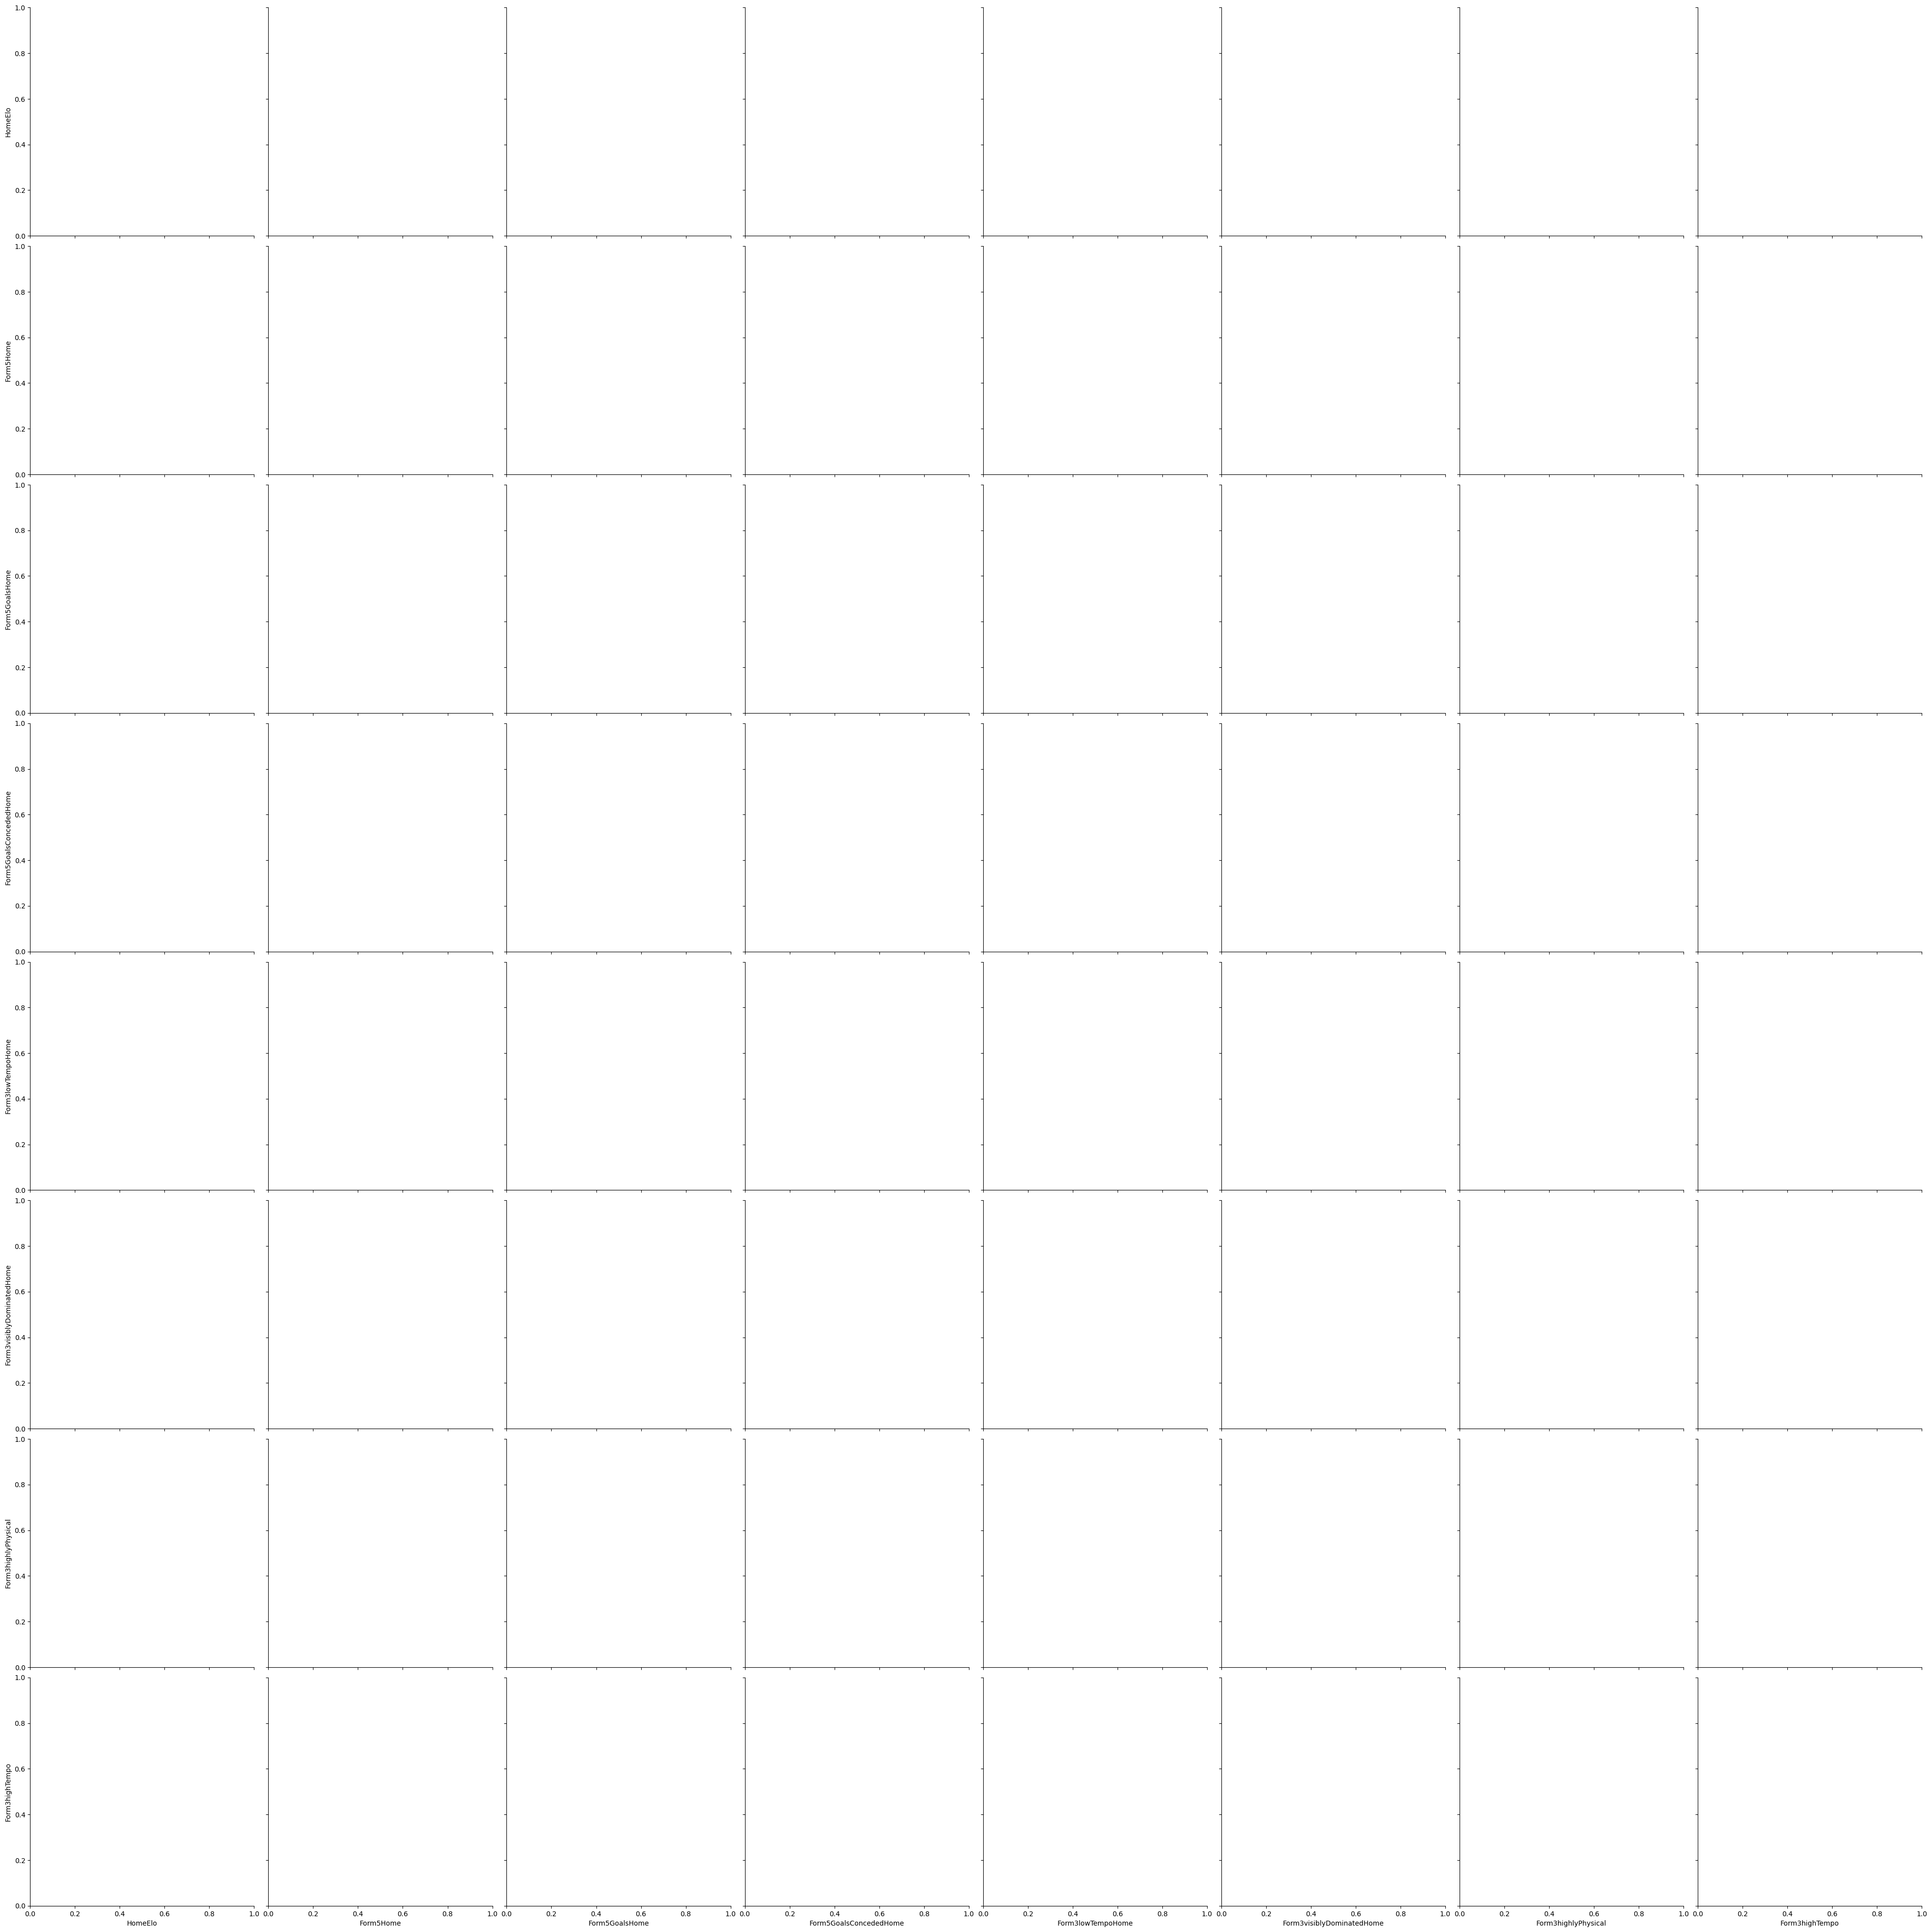

In [ ]:
import seaborn as sns

cols_relation = [
    'EloDiff', 'Form5Difference', 'Form5GoalsDiff', 'Form5GoalsConcededDiff', 'Form3lowTempoDiff', 'Form3visiblyDominatedDiff', 'Form5TargetDiff', 'DrawLikeliHood'
]
random_df = df_min.sample(1000)

sns.pairplot(random_df, x_vars=cols_relation, y_vars=cols_relation, hue="Target", palette=['#2ecc71', '#95a5a6', '#e74c3c'], height=5).add_legend()

--- Correlations for HomeElo ---
HomeElo                      1.000000
Form5Home                    0.387408
Form5GoalsHome               0.401511
Form5GoalsConcededHome      -0.217885
Form3lowTempoHome           -0.052475
Form3visiblyDominatedHome    0.156924
Form3highlyPhysical         -0.188106
Form3highTempo              -0.016265
Name: HomeElo, dtype: float64


--- Correlations for Form5Home ---
HomeElo                      0.387408
Form5Home                    1.000000
Form5GoalsHome               0.690897
Form5GoalsConcededHome      -0.629286
Form3lowTempoHome            0.006117
Form3visiblyDominatedHome    0.070042
Form3highlyPhysical         -0.015578
Form3highTempo              -0.007889
Name: Form5Home, dtype: float64


--- Correlations for Form5GoalsHome ---
HomeElo                      0.401511
Form5Home                    0.690897
Form5GoalsHome               1.000000
Form5GoalsConcededHome      -0.162465
Form3lowTempoHome           -0.044093
Form3visiblyDominatedHome   

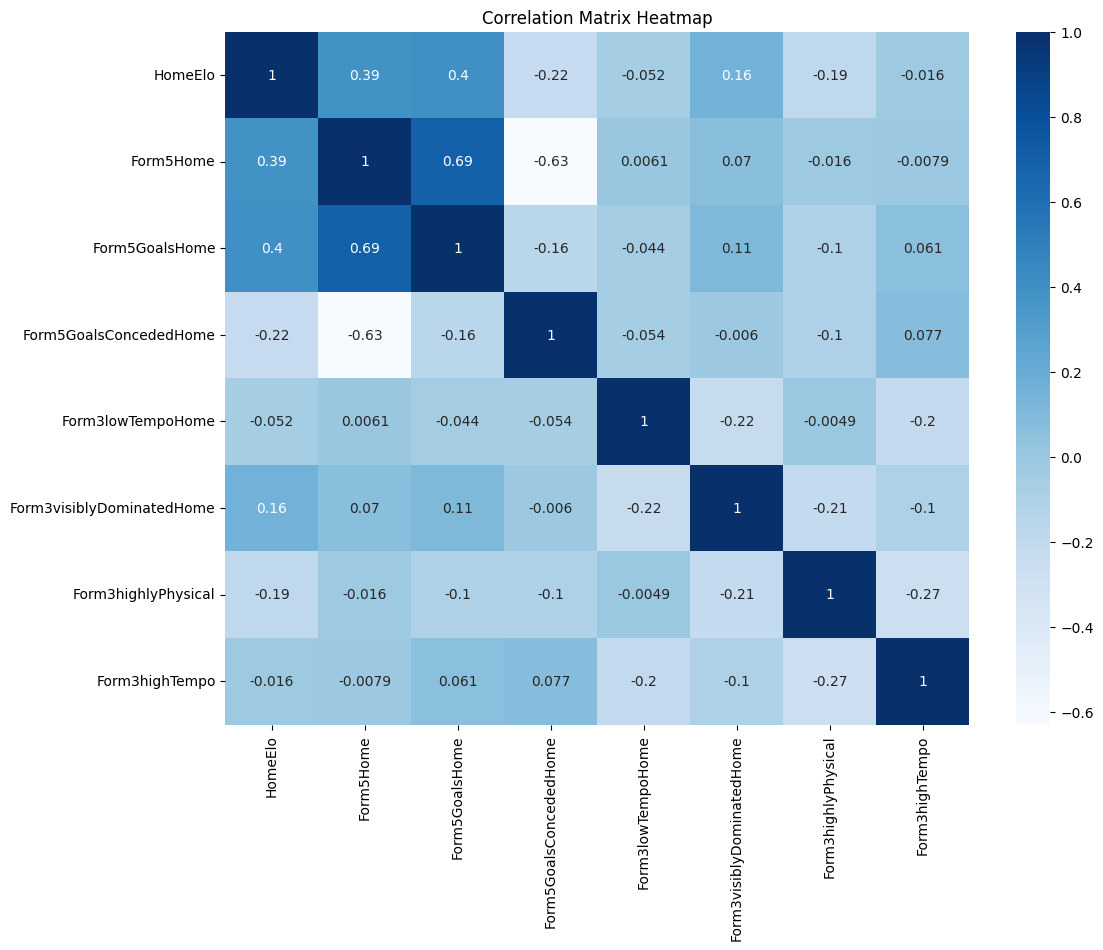

In [ ]:
corrmat = df_min[cols_relation].corr()
for feature_name, correlation_scores in corrmat.items():
    print(f"--- Correlations for {feature_name} ---")
    print(correlation_scores)
    print("\n")

plt.figure(figsize=(12,9))
sns.heatmap(corrmat, cmap="Blues",annot=True);
plt.title('Correlation Matrix Heatmap')
plt.show()

### Define Training/Eval/Test Sets

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

num_features = df_min.shape[1] - 1
print(num_features)

y_labels = df_min.iloc[:, num_features]
X_features = df_min.drop(df_min.columns[num_features], axis=1)

29


In [ ]:
from sklearn.model_selection import train_test_split
X, X_test, y, y_test = train_test_split(
    X_features, y_labels, test_size=0.20, random_state=42, shuffle=False
)

X_train, x_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print(X_train.shape)
print(x_eval.shape)
print(X_test.shape)

(19626, 29)
(4907, 29)
(6134, 29)


In [ ]:
scaler = StandardScaler()

# scale data based on the mean and std of the training data
X_train = scaler.fit_transform(X_train) # computes mean and std of training set
X_test = scaler.transform(X_test)
x_eval = scaler.transform(x_eval)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.long)

X_eval = torch.tensor(x_eval, dtype=torch.float32)
y_eval = torch.tensor(y_eval.values, dtype=torch.long)

train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=False)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
eval_dataloader = DataLoader(TensorDataset(X_eval, y_eval), batch_size=64, shuffle=False)


### Model Definition

In [ ]:
class ModelClassifier(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        
        self.lin1 = nn.Linear(num_features, out_features=128) # linear applies x * W^T + b
        self.bn1 = nn.BatchNorm1d(128)
        
        self.lin2 = nn.Linear(128, out_features=64)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.lin3 = nn.Linear(64, out_features=32)
        self.bn3 = nn.BatchNorm1d(32)
    
        self.lin4 = nn.Linear(32, out_features=16)
        self.bn4 = nn.BatchNorm1d(16)
        
        self.output_layer = nn.Linear(16, out_features=3) # output layer
        
        self.hidden_act = nn.LeakyReLU(negative_slope=0.1)
        # self.output_act = nn.Softmax() # defines the SoftMax behaviour for more than 2 classes classification
        self.dropout = nn.Dropout(p=0.3)
        
    def forward(self, x):
        """
            Forward pass for the model. BatchNorm NOT activated.
        """        
        # activation of the first layer
        x = self.lin1(x)
        #x = self.bn1(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        # activation of the second layer
        x = self.lin2(x)
        #x = self.bn2(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.lin3(x)
        #x = self.bn3(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.lin4(x)
        #x = self.bn4(x)
        x = self.hidden_act(x)
        x = self.dropout(x)
        
        x = self.output_layer(x)        
        return x

Define some usefull elements for the training like:
- Initialize the model;
- Initialize hyperparameters (learning rate, weight decay);
- Initialize Optimizers;

In [ ]:
EPOCHS = 50
EPOCHS_STOP = 5

lr = 1e-03
weight_decay = 1e-3
weight_result = True
weights = torch.tensor([1.0, 1.20, 1.0]).to(device) if weight_result else None

criterion = nn.CrossEntropyLoss(weight=weights) # adding weights in order to make some predictions more predictable (model never predicts 1 so far)
model = ModelClassifier(num_features=num_features)
model.to(device)
model.train(True)

optimizer = optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    patience=10,
    factor=0.8
)

### EVAL FUNCTION 

In [ ]:
def update_confusion_matrix(logits, batch_labels, results):
    """
    Updates the TP, TN, FP, FN counters in the 'stats' dictionary.
    INPUTS:
            - logits: used to compute predictions
            - batch_labels: used to compute metrics based on predictions
            - results: dictionary in which we accumulate some metrics
    """
    if hasattr(logits, 'cpu'): 
        logits = logits.cpu().detach().numpy()
    if hasattr(batch_labels, 'cpu'):
        batch_labels = batch_labels.cpu().detach().numpy()
    # Get predictions
    predictions = np.argmax(logits, axis=1)

    # Calculate overlaps using Bitwise AND (&)
    # Boolean arrays act as 0/1 integers when summed
    results['TW'] += ((predictions == 0) & (batch_labels == 0)).sum()
    results['FW_D'] += ((predictions == 0) & (batch_labels == 1)).sum()
    results['FW_L'] += ((predictions == 0) & (batch_labels == 2)).sum()
    
    results['TD'] += ((predictions == 1) & (batch_labels == 1)).sum()
    results['FD_W'] += ((predictions == 1) & (batch_labels == 0)).sum()
    results['FD_L'] += ((predictions == 1) & (batch_labels == 2)).sum()
    
    results['TL'] += ((predictions == 2) & (batch_labels == 2)).sum()
    results['FL_W'] += ((predictions == 2) & (batch_labels == 0)).sum()
    results['FL_D'] += ((predictions == 2) & (batch_labels == 1)).sum()
    

In [ ]:
def eval_model(model, dataloader, loss_fn, device):
    """
        Function that validates the model
        INPUTS:
            - model: our defined class model;
            - dataloader: an instance of the validation dataloader containing samples and labels;
            - loss_fn: loss function (just for health checking the results);
            - device: gpu or cpu boolean value.
    """
    
    model.eval()  # Set to evaluation mode

    results = {
        "TW": 0, "FW_D": 0, "FW_L": 0,
        "FD_W": 0, "TD": 0, "FD_L": 0,
        "FL_W": 0, "FL_D": 0, "TL": 0
    }

    total_loss = 0
    correct = 0
    samples = 0
    metrics = {} # further implementation
    
    with torch.no_grad():
        for input_batch, label_batch in dataloader:
            input_batch = input_batch.to(device)
            label_batch = label_batch.to(device)
            
            label_batch = label_batch.long()
            
            predict = model(input_batch)
            
            loss = loss_fn(predict, label_batch)
            
            total_loss += loss.item()
            predictions = torch.argmax(predict, dim=1)
            correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
            samples += label_batch.size(0) # Add batch size (e.g., 32)
            
            update_confusion_matrix(predict, label_batch, results)
                
    model.train()  # Set back to training mode
    metrics["Avg_loss"] = total_loss / len(dataloader)
    metrics["Accuracy"] = correct / samples
    
    return metrics, results

### TRAINING

In [ ]:
train_loss = []
eval_loss = []
model.train(True)

k_values = [1.0, 1.1, 1.2, 1.30, 1.50]

# set these values for the early stopping
best_loss = float('inf')
count = 0
for epoch in range(EPOCHS):
    total_loss = 0
    correct = 0
    for input_batch, label_batch in train_dataloader:
        input_batch = input_batch.to(device)
        label_batch = label_batch.to(device)
        
        label_batch = label_batch.long()
        
        logits = model(input_batch)
        
        # zero-out the gradients
        optimizer.zero_grad()
        loss = criterion(logits, label_batch)
        
        loss.backward() # perform backpropagation
        
        # compute the next step for the optimizer and the lr_scheduler
        optimizer.step()
        
        # compute total training loss and correct predictions
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=1)
        
        correct += (predictions == label_batch).sum().item() # add up the number of correct training predictions
                
    metrics, results = eval_model(model, eval_dataloader, criterion, device=device)
    lr_scheduler.step(metrics["Avg_loss"])
    
    if epoch % 10 == 0:
        print(f"Loss for epoch nr. {epoch + 1}: {total_loss:.2f}")
        print(f"Correct predictions for epoch nr. {epoch + 1}: {correct}\n")
        
        #for logit, label in zip(logits, label_batch):
        #    prediction = F.softmax(logit, dim=0)
        #    print(f"Our prediction: {prediction}")
        #    print(f"True prediction: {label}")
        print(f"Eval Loss for epoch nr. {epoch + 1}: {metrics["Avg_loss"]:.2f}")
        print(f"Eval percentage of correct predictions for epoch nr. {epoch + 1}: {metrics["Accuracy"]*100:.2f}\n")
    
    train_loss.append(total_loss) # append loss relative to the epoch
    eval_loss.append(metrics["Avg_loss"])
        
    if total_loss < best_loss:
        best_loss = total_loss
        count = 0 # reset the count because we improved the loss## Decision Trees and Random Classifier
    else:
        count += 1
        
    # if count == EPOCHS_STOP:
    #     print(f"Early stopping at epoch nr. {epoch + 1}")
    #     break # we stop the training if we have no improvement   

mean_train_loss = np.mean(train_loss)
mean_eval_loss = np.mean(eval_loss)
print(f"Mean train loss: {mean_train_loss:.4f}")
print(f"Mean eval loss: {mean_eval_loss:.4f}")
print(f"Best loss of the training: {best_loss:.4f}")


Loss for epoch nr. 1: 326.51
Correct predictions for epoch nr. 1: 8806

Eval Loss for epoch nr. 1: 1.01
Eval percentage of correct predictions for epoch nr. 1: 51.11

Loss for epoch nr. 11: 313.55
Correct predictions for epoch nr. 11: 9775

Eval Loss for epoch nr. 11: 1.01
Eval percentage of correct predictions for epoch nr. 11: 51.52

Loss for epoch nr. 21: 311.85
Correct predictions for epoch nr. 21: 9822

Eval Loss for epoch nr. 21: 1.01
Eval percentage of correct predictions for epoch nr. 21: 50.93

Loss for epoch nr. 31: 310.66
Correct predictions for epoch nr. 31: 9975

Eval Loss for epoch nr. 31: 1.01
Eval percentage of correct predictions for epoch nr. 31: 50.85

Loss for epoch nr. 41: 309.18
Correct predictions for epoch nr. 41: 9990

Eval Loss for epoch nr. 41: 1.01
Eval percentage of correct predictions for epoch nr. 41: 50.54

Mean train loss: 311.8303
Mean eval loss: 1.0095
Best loss of the training: 307.5115


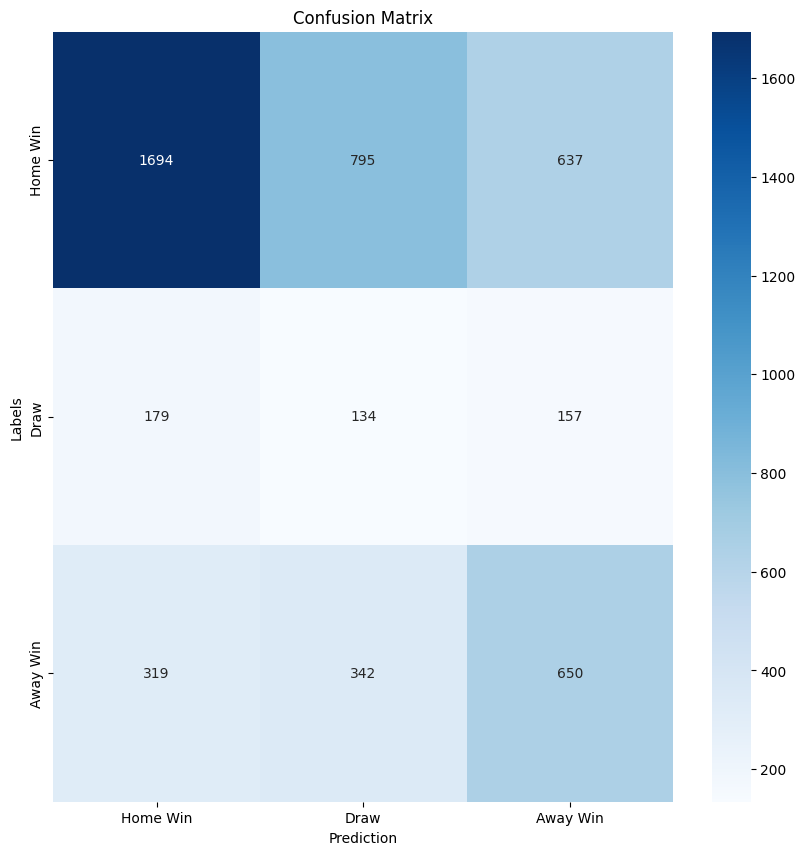

In [ ]:
def print_confusion_matrix(cm, title):
    """
        Prints a confusion matrix of the data
    """
    
    classes = ["Home Win", "Draw", "Away Win"]
    data = np.array([
        [cm["TW"], cm["FW_D"], cm["FW_L"]],
        [cm["FD_W"], cm["TD"], cm["FD_L"]],
        [cm["FL_W"], cm["FL_D"], cm["TL"]],
    ])
    
    plt.figure(figsize=(10,10))
    sns.heatmap(data, annot=True, fmt='d', xticklabels=classes, cmap="Blues", yticklabels=classes)
    
    plt.ylabel("Labels")
    plt.xlabel("Prediction")
    plt.title(title)
    plt.show()
    
print_confusion_matrix(results, title="Confusion Matrix")

## Decision Trees and Random Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report

tree_models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=10),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10) # n of estimators to 100 --> Decision trees in the forest
}

In [ ]:
tree_metrics = []
max_depth_values = [3, 5, 8, 10, 20]

for k in max_depth_values:
    for name, tree_model in tree_models.items():
        print(f"Starting to fit the training set with the {name} method with max_depth={k}")
        tree_model.set_params(max_depth=k)
        
        tree_model.fit(X_train, y_train)
        
        prediction = tree_model.predict(X_eval)
        
        accuracy = accuracy_score(y_eval, prediction)
        
        # calculate the prediction for all three classes
        precision = precision_score(y_eval, prediction, average='macro', zero_division=0)
        
        metrics = {
            'method': name,
            'max_depth': k,
            'accuracy': accuracy,
            'precision': precision
        }
        tree_metrics.append(metrics)
        
print("Completed.")

Starting to fit the training set with the DecisionTree method with max_depth=3
Starting to fit the training set with the RandomForest method with max_depth=3
Starting to fit the training set with the DecisionTree method with max_depth=5
Starting to fit the training set with the RandomForest method with max_depth=5
Starting to fit the training set with the DecisionTree method with max_depth=8
Starting to fit the training set with the RandomForest method with max_depth=8
Starting to fit the training set with the DecisionTree method with max_depth=10
Starting to fit the training set with the RandomForest method with max_depth=10
Starting to fit the training set with the DecisionTree method with max_depth=20
Starting to fit the training set with the RandomForest method with max_depth=20
Completed.


In [ ]:
importances = tree_model.feature_importances_
feature_names = X_features.columns

sorted_importances = sorted(dict(zip(feature_names, importances)).items(), key=lambda item: item[1], reverse=True)

for name, importance in sorted_importances:
    print(f"Name: {name}")
    print(f"Importance: {importance*100}\n")

Name: AwayElo
Importance: 5.440438417835517

Name: HomeElo
Importance: 5.278940844019575

Name: DrawLikeliHood
Importance: 5.075152048110154

Name: Form5PericolosityAway
Importance: 4.259649052576651

Name: Form5PericolosityHome
Importance: 4.232515105389677

Name: Form3visiblyDominatedAway
Importance: 3.9152851152182597

Name: EloDifference5Away
Importance: 3.9028929933780687

Name: Form3highTempo
Importance: 3.8928394997724145

Name: Form3lowTempoAway
Importance: 3.886510974892409

Name: EloDifference5Home
Importance: 3.8791380178621

Name: Form3lowTempoHome
Importance: 3.8635881770105835

Name: Form3highlyPhysical
Importance: 3.789191097573167

Name: Form3visiblyDominatedHome
Importance: 3.761304266897942

Name: Form5CorrectnessHome
Importance: 3.7064231189854238

Name: EloDifference3Home
Importance: 3.6369832410713605

Name: EloDifference3Away
Importance: 3.574498591144378

Name: Form5CorrectnessAway
Importance: 3.5543295103561605

Name: Form5ShotsHome
Importance: 3.496286909682944

In [ ]:
def print_metrics(metric):
    print(f"Method: {metric["method"]}")
    print(f"Max Depth: {metric["max_depth"]}")
    print(f"Accuracy: {metric["accuracy"]*100:.2f}%")
    print(f"Precision: {metric["precision"]*100:.2f}%\n")
    
for metric in tree_metrics:
    print_metrics(metric)

Method: DecisionTree
Max Depth: 3
Accuracy: 48.42%
Precision: 31.84%

Method: RandomForest
Max Depth: 3
Accuracy: 49.70%
Precision: 33.68%

Method: DecisionTree
Max Depth: 5
Accuracy: 49.32%
Precision: 41.26%

Method: RandomForest
Max Depth: 5
Accuracy: 49.62%
Precision: 32.93%

Method: DecisionTree
Max Depth: 8
Accuracy: 49.54%
Precision: 43.11%

Method: RandomForest
Max Depth: 8
Accuracy: 50.17%
Precision: 44.19%

Method: DecisionTree
Max Depth: 10
Accuracy: 47.81%
Precision: 41.99%

Method: RandomForest
Max Depth: 10
Accuracy: 50.34%
Precision: 43.49%

Method: DecisionTree
Max Depth: 20
Accuracy: 41.61%
Precision: 39.26%

Method: RandomForest
Max Depth: 20
Accuracy: 49.20%
Precision: 42.08%

